<a href="https://colab.research.google.com/github/averkina/Bagging-GB-XGB/blob/main/Bagging%2C_GB%2C_XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 2_preprocessed.zip to 2_preprocessed.zip


In [ ]:
import os
import zipfile

with zipfile.ZipFile('2_preprocessed.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

Loading...
dataset is ready, rows: 9047247

=== Instant: Voltage, Current, temperature ===
train rows: 7406375, test rows: 1640872
Bagging  final: test MAE=8.0055 %SOC, R2=0.8512
GBoost   final: test MAE=1.9652 %SOC, R2=0.9899
XGBoost  final: test MAE=2.0189 %SOC, R2=0.9894

=== With state: + Charge ===
train rows: 7406375, test rows: 1640872
Bagging  final: test MAE=5.8854 %SOC, R2=0.9318
GBoost   final: test MAE=0.2911 %SOC, R2=0.9998
XGBoost  final: test MAE=0.2995 %SOC, R2=0.9998

Saved Figure.png


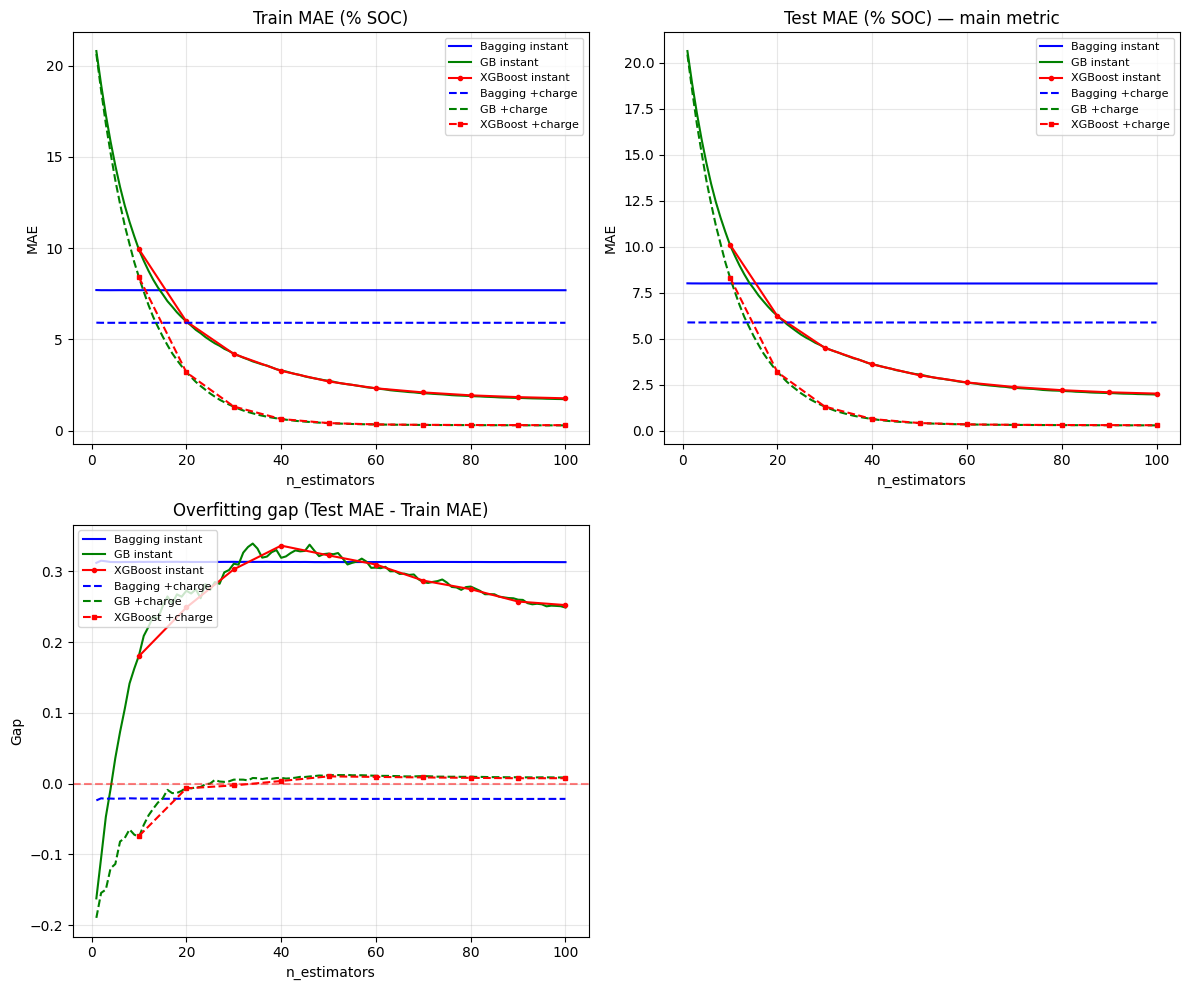

In [ ]:
import os
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeRegressor

base_path = ("2_preprocessed")
MAX_ESTIMATORS = 100
TEST_SIZE_FRACTION = 0.2
RANDOM_STATE = 42

def load_dataset(base: str) -> pd.DataFrame:
    frames = []
    for temp in [5, 15, 25, 35, 45]:
        folder = f"{base}/JY_SOC_{temp}deg"
        for name in sorted(os.listdir(folder)):
            if not name.endswith(".csv"):
                continue
            path = f"{folder}/{name}"
            df = pd.read_csv(path)
            df["file_key"] = f"{temp}deg/{name}"#идентификатор, чтобы смотреть откуда пришла строка
            df["Charge"] = (df["Current"] / 36000.0).cumsum()
            frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    return out

def regression_scores(y_true, y_pred) -> tuple[float, float, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def bagging(x_train, y_train, x_test, y_test, max_estimators: int):
    reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE),#RS фиксируем выбор дерева решений
        n_estimators=1,#по умолчанию значение 10
        warm_start=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    test_mae, test_rmse, test_r2 = [], [], []
    train_mae, train_rmse, train_r2 = [], [], []
    for i in range(1, max_estimators + 1):
        reg.n_estimators = i
        reg.fit(x_train, y_train)
        pred_train = reg.predict(x_train)
        pred_test = reg.predict(x_test)
        mae_train, rmse_train, r2_train = regression_scores(y_train, pred_train)
        mae_test, rmse_test, r2_test = regression_scores(y_test, pred_test)
        train_mae.append(mae_train)
        train_rmse.append(rmse_train)
        train_r2.append(r2_train)
        test_mae.append(mae_test)
        test_rmse.append(rmse_test)
        test_r2.append(r2_test)
    return reg, train_mae, test_mae, train_rmse, test_rmse, train_r2, test_r2

def gradient_boosting(x_train, y_train, x_test, y_test, max_estimators: int):
    reg = GradientBoostingRegressor(
        max_depth=2,
        learning_rate=0.1,
        n_estimators=1,
        warm_start=True,
        random_state=RANDOM_STATE,
    )
    test_mae, test_rmse, test_r2 = [], [], []
    train_mae, train_rmse, train_r2 = [], [], []
    for i in range(1, max_estimators + 1):
        reg.n_estimators = i
        reg.fit(x_train, y_train)
        pred_train = reg.predict(x_train)
        pred_test = reg.predict(x_test)
        mae_train, rmse_train, r2_train = regression_scores(y_train, pred_train)
        mae_test, rmse_test, r2_test = regression_scores(y_test, pred_test)
        train_mae.append(mae_train)
        train_rmse.append(rmse_train)
        train_r2.append(r2_train)
        test_mae.append(mae_test)
        test_rmse.append(rmse_test)
        test_r2.append(r2_test)
    return reg, train_mae, test_mae, train_rmse, test_rmse, train_r2, test_r2

def xgboost_regressor(x_train, y_train, x_test, y_test, max_estimators: int):

    test_mae, test_rmse, test_r2 = [], [], []
    train_mae, train_rmse, train_r2 = [], [], []

    for i in range(10, max_estimators + 1, 10):
        reg = xgb.XGBRegressor(max_depth=2,learning_rate=0.1,n_estimators=i,random_state=RANDOM_STATE,n_jobs=-1)
        reg.fit(x_train, y_train)

        pred_train = reg.predict(x_train)
        pred_test = reg.predict(x_test)

        mae_train, rmse_train, r2_train = regression_scores(y_train, pred_train)
        mae_test, rmse_test, r2_test = regression_scores(y_test, pred_test)

        train_mae.append(mae_train)
        train_rmse.append(rmse_train)
        train_r2.append(r2_train)
        test_mae.append(mae_test)
        test_rmse.append(rmse_test)
        test_r2.append(r2_test)
    return reg, train_mae, test_mae, train_rmse, test_rmse, train_r2, test_r2

def run_suite(name: str, train_idx, test_idx, X, y):
    x_train, x_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print(f"\n=== {name} ===")
    print(f"train rows: {len(y_train)}, test rows: {len(y_test)}")
#распаковываю кортеж, игнорируя некоторые значения
    _, bag_train_mae, bag_test_mae, _, _, _, bag_test_r2 = bagging(x_train, y_train, x_test, y_test, MAX_ESTIMATORS)
    _, gb_train_mae, gb_test_mae, _, _, _, gb_test_r2 = gradient_boosting(x_train, y_train, x_test, y_test, MAX_ESTIMATORS)
    _, xgb_train_mae, xgb_test_mae, _, _, _, xgb_test_r2 = xgboost_regressor(x_train, y_train, x_test, y_test, MAX_ESTIMATORS)
    print(
        f"Bagging  final: test MAE={bag_test_mae[-1]:.4f} %SOC, "
        f"R2={bag_test_r2[-1]:.4f}"
    )
    print(
        f"GBoost   final: test MAE={gb_test_mae[-1]:.4f} %SOC, "
        f"R2={gb_test_r2[-1]:.4f}"
    )
    print(f"XGBoost  final: test MAE={xgb_test_mae[-1]:.4f} %SOC, R2={xgb_test_r2[-1]:.4f}")

    return (bag_train_mae, bag_test_mae, bag_test_r2,
            gb_train_mae, gb_test_mae, gb_test_r2,
            xgb_train_mae, xgb_test_mae, xgb_test_r2)

def main():
    print("Loading...")
    dataset = load_dataset(base_path)
    print("dataset is ready, rows:", len(dataset))

    y = (dataset["SOC"].values * 100.0).ravel()  # целевые значения
    x_instant = dataset[["Voltage", "Current", "Temperature"]].values
    x_instant_charge = dataset[["Voltage", "Current", "Temperature", "Charge"]].values  # матрицы моих признаков
    groups = dataset["file_key"].values  # метки файлов для каждой строки

    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE_FRACTION,
                                 random_state=RANDOM_STATE)  # здесь разбиение - целые файлы сохраняются
    train_idx, test_idx = next(splitter.split(x_instant_charge, y, groups=groups))
    '''создаю генератор вида кортеж с двумя массивами и достаю из него значение,
    если бы у меня split() возвращал список, то было бы плохо, так как датасет огромный'''
    set_instant = run_suite("Instant: Voltage, Current, temperature", train_idx, test_idx, x_instant, y)
    set_instant_charge = run_suite("With state: + Charge", train_idx, test_idx, x_instant_charge, y)

    (bag_train_i, bag_test_i, _,
        gb_train_i, gb_test_i, _,
        xgb_train_i, xgb_test_i, _) = set_instant

    (bag_train_s, bag_test_s, _,
        gb_train_s, gb_test_s, _,
        xgb_train_s, xgb_test_s, _) = set_instant_charge

    epochs = np.arange(1, MAX_ESTIMATORS + 1)
    epochs_xgb = np.arange(10, MAX_ESTIMATORS + 1, 10)

    plt.figure(figsize=(12, 10))

    # График 1:
    plt.subplot(2, 2, 1)
    plt.plot(epochs, bag_train_i, 'b-', label="Bagging instant", linewidth=1.5)
    plt.plot(epochs, gb_train_i, 'g-', label="GB instant", linewidth=1.5)
    plt.plot(epochs_xgb, xgb_train_i, 'r-', label="XGBoost instant", linewidth=1.5, marker='o', markersize=3)
    plt.plot(epochs, bag_train_s, 'b--', label="Bagging +charge", linewidth=1.5)
    plt.plot(epochs, gb_train_s, 'g--', label="GB +charge", linewidth=1.5)
    plt.plot(epochs_xgb, xgb_train_s, 'r--', label="XGBoost +charge", linewidth=1.5, marker='s', markersize=3)
    plt.title("Train MAE (% SOC)", fontsize=12)
    plt.xlabel("n_estimators")
    plt.ylabel("MAE")
    plt.legend(fontsize=8, loc='upper right')
    plt.grid(True, alpha=0.3)

    # График 2: Test MAE
    plt.subplot(2, 2, 2)
    plt.plot(epochs, bag_test_i, 'b-', label="Bagging instant", linewidth=1.5)
    plt.plot(epochs, gb_test_i, 'g-', label="GB instant", linewidth=1.5)
    plt.plot(epochs_xgb, xgb_test_i, 'r-', label="XGBoost instant", linewidth=1.5, marker='o', markersize=3)
    plt.plot(epochs, bag_test_s, 'b--', label="Bagging +charge", linewidth=1.5)
    plt.plot(epochs, gb_test_s, 'g--', label="GB +charge", linewidth=1.5)
    plt.plot(epochs_xgb, xgb_test_s, 'r--', label="XGBoost +charge", linewidth=1.5, marker='s', markersize=3)
    plt.title("Test MAE (% SOC) — main metric", fontsize=12)
    plt.xlabel("n_estimators")
    plt.ylabel("MAE")
    plt.legend(fontsize=8, loc='upper right')
    plt.grid(True, alpha=0.3)

    # График 3: Разница Test - Train
    plt.subplot(2, 2, 3)
    plt.plot(epochs, np.array(bag_test_i) - np.array(bag_train_i), 'b-', label="Bagging instant", linewidth=1.5)
    plt.plot(epochs, np.array(gb_test_i) - np.array(gb_train_i), 'g-', label="GB instant", linewidth=1.5)
    plt.plot(epochs_xgb, np.array(xgb_test_i) - np.array(xgb_train_i), 'r-', label="XGBoost instant", linewidth=1.5, marker='o', markersize=3)
    plt.plot(epochs, np.array(bag_test_s) - np.array(bag_train_s), 'b--', label="Bagging +charge", linewidth=1.5)
    plt.plot(epochs, np.array(gb_test_s) - np.array(gb_train_s), 'g--', label="GB +charge", linewidth=1.5)
    plt.plot(epochs_xgb, np.array(xgb_test_s) - np.array(xgb_train_s), 'r--', label="XGBoost +charge", linewidth=1.5, marker='s', markersize=3)
    plt.title("Overfitting gap (Test MAE - Train MAE)", fontsize=12)
    plt.xlabel("n_estimators")
    plt.ylabel("Gap")
    plt.legend(fontsize=8, loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig("Figure.png", dpi=150)

Dataset id ready

=== Only charge: ===
train rows: 7406375, test rows: 1640872
Bagging  final: test MAE=0.0589 %SOC, R2=0.9318
GBoost   final: test MAE=0.0029 %SOC, R2=0.9998
XGBoost  final: test MAE=0.0030 %SOC, R2=0.9998


TypeError: unsupported operand type(s) for -: 'list' and 'list'

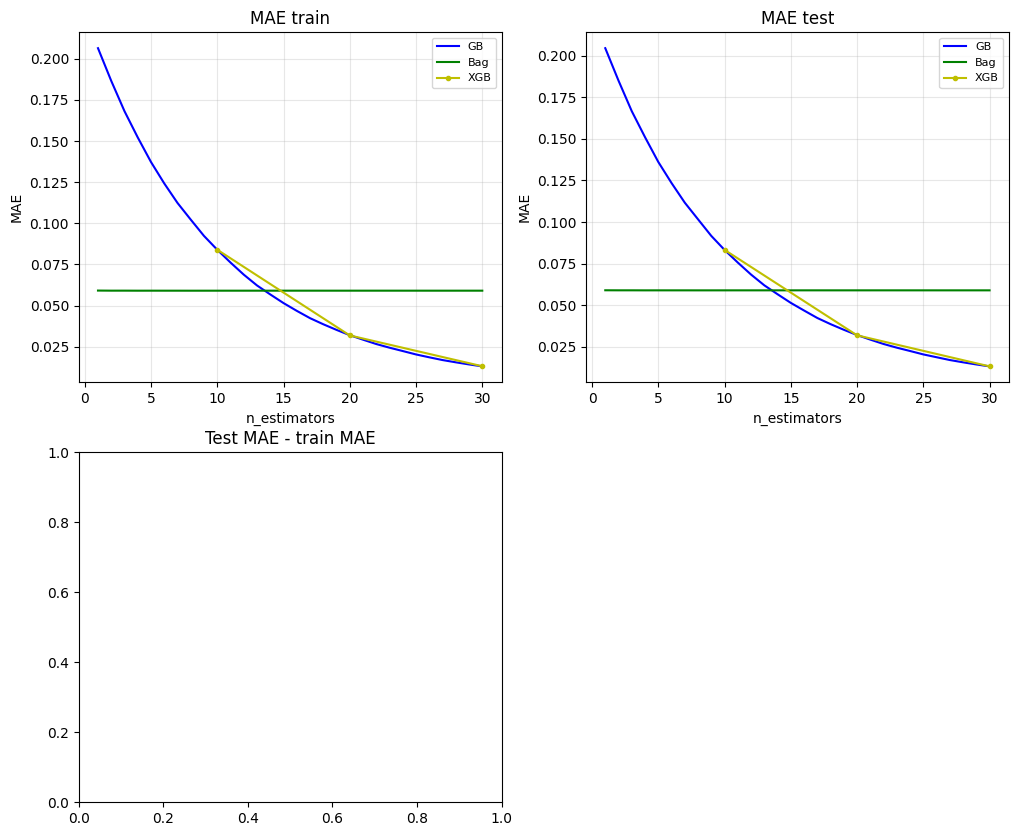

In [ ]:
def main1():
  dataset = load_dataset(base_path)
  print("Dataset id ready")
  y = dataset["SOC"].values.ravel()*100
  x = dataset[["Charge"]].values
  groups = dataset["file_key"].values
  splitter = GroupShuffleSplit(n_splits = 1, test_size = TEST_SIZE_FRACTION, random_state=RANDOM_STATE)
  train_idx, test_idx = next(splitter.split(x, y, groups=groups))
  set_only_charge = run_suite("Only charge:", train_idx, test_idx, x, y)
  (bag_train_i, bag_test_i, _, gb_train_i, gb_test_i, _, xgb_train_i, xgb_test_i, _) = set_only_charge
  bag_train_i = bag_train_i[:30]
  bag_test_i = bag_test_i[:30]
  gb_train_i = gb_train_i[:30]
  gb_test_i = gb_test_i[:30]
  xgb_train_i = xgb_train_i[:3]
  xgb_test_i = xgb_test_i[:3]

  epochs = np.arange(1, 31)
  epochs_xgb = np.arange(10, 31, 10)

  plt.figure(figsize = (12,10))
  plt.subplot(221)
  plt.title('MAE train')
  plt.plot(epochs, gb_train_i, 'b-', label = 'GB', linewidth = 1.5)
  plt.plot(epochs, bag_train_i, 'g-', label = 'Bag', linewidth = 1.5)
  plt.plot(epochs_xgb, xgb_train_i, 'y-', label = 'XGB', linewidth = 1.5, marker = 'o', markersize = 3)
  plt.xlabel('n_estimators')
  plt.ylabel('MAE')
  plt.grid(True, alpha = 0.3)
  plt.legend(fontsize = 8, loc = 'upper right')

  plt.subplot(222)
  plt.title('MAE test')
  plt.plot(epochs, gb_test_i, 'b-', label = 'GB', linewidth = 1.5)
  plt.plot(epochs, bag_test_i, 'g-', label = 'Bag', linewidth = 1.5)
  plt.plot(epochs_xgb, xgb_test_i, 'y-', label = 'XGB', linewidth = 1.5, marker = 'o', markersize = 3)
  plt.xlabel('n_estimators')
  plt.ylabel('MAE')
  plt.grid(True, alpha = 0.3)
  plt.legend(fontsize = 8, loc = 'upper right')

  plt.subplot(223)
  plt.title('Test MAE - train MAE')
  plt.plot(epochs, np.array(gb_test_i) - np.array(gb_train_i), 'b-', label = 'GB', linewidth = 1.5)
  plt.plot(epochs, np.array(bag_test_i) - np.array(bag_train_i), 'g-', label = 'Bag', linewidth = 1.5)
  plt.plot(epochs_xgb, np.array(xgb_test_i) - np.array(xgb_train_i), 'y-', label = 'XGB', linewidth = 1.5, marker = 'o', markersize = 3)
  plt.xlabel('n_estimators')
  plt.ylabel('MAE')
  plt.grid(True, alpha = 0.3)
  plt.legend(fontsize = 8, loc = 'upper right')

  plt.tight_layout()
  plt.savefig("FigureCharge.png", dpi = 150)

main1()